# Notebook demo - Blood Cell Classification

Hướng đúng của project: **Recognition (Classification)** là chính.
`dataset2-master` dùng để train WBC classifier. `dataset-master` chỉ dùng để demo ảnh kính hiển vi, WBC proposal/crop và RBC detector hỗ trợ.


## 1. Import và setup path


In [3]:
import sys
import random
from pathlib import Path
from subprocess import run
from collections import Counter
import xml.etree.ElementTree as ET
from subprocess import run

import cv2
import matplotlib.pyplot as plt
import torch
from torchvision import datasets

ROOT = Path.cwd()
for parent in [ROOT] + list(ROOT.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError("Kh?ng t?m th?y project root ch?a th? m?c src")

sys.path.append(str(PROJECT_ROOT))

from src import CellPipeline, WBCProposal, load_wbc_classifier, load_rbc_detector
from src.annotation_converter import AnnotationConverter
from src.model.wbc_classifier import predict_class
from src.visualization import draw_boxes

print("Project root:", PROJECT_ROOT)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Project root: f:\py\XLAS\HeaWeb
Device: cpu


## 2. Khai báo dataset


In [2]:
DATASET_MASTER = PROJECT_ROOT / "dataset-master" / "dataset-master"
DATASET2_MASTER = PROJECT_ROOT / "dataset2-master" / "dataset2-master"

JPEG_DIR = DATASET_MASTER / "JPEGImages"
ANNOTATION_DIR = DATASET_MASTER / "Annotations"
TRAIN_DIR = DATASET2_MASTER / "images" / "TRAIN"
TEST_DIR = DATASET2_MASTER / "images" / "TEST"

for name, path in {
    "JPEG_DIR": JPEG_DIR,
    "ANNOTATION_DIR": ANNOTATION_DIR,
    "TRAIN_DIR": TRAIN_DIR,
    "TEST_DIR": TEST_DIR,
}.items():
    print(f"{name}: {path.exists()} | {path}")


JPEG_DIR: True | f:\py\XLAS\HeaWeb\dataset-master\dataset-master\JPEGImages
ANNOTATION_DIR: True | f:\py\XLAS\HeaWeb\dataset-master\dataset-master\Annotations
TRAIN_DIR: True | f:\py\XLAS\HeaWeb\dataset2-master\dataset2-master\images\TRAIN
TEST_DIR: True | f:\py\XLAS\HeaWeb\dataset2-master\dataset2-master\images\TEST


## 3. Kiểm tra dataset chính cho classification


In [5]:
train_ds_info = datasets.ImageFolder(TRAIN_DIR)
test_ds_info = datasets.ImageFolder(TEST_DIR)

train_counts = Counter(label for _, label in train_ds_info.samples)
test_counts = Counter(label for _, label in test_ds_info.samples)

print("Classes:", train_ds_info.classes)
print("Train samples:", len(train_ds_info))
print("Test samples:", len(test_ds_info))

print("\nTrain count by class:")
for idx, class_name in enumerate(train_ds_info.classes):
    print(f"  {class_name}: {train_counts[idx]}")

print("\nTest count by class:")
for idx, class_name in enumerate(test_ds_info.classes):
    print(f"  {class_name}: {test_counts[idx]}")


Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Train samples: 9957
Test samples: 2487

Train count by class:
  EOSINOPHIL: 2497
  LYMPHOCYTE: 2483
  MONOCYTE: 2478
  NEUTROPHIL: 2499

Test count by class:
  EOSINOPHIL: 623
  LYMPHOCYTE: 620
  MONOCYTE: 620
  NEUTROPHIL: 624


## 4. Xem một ảnh single-cell mà classifier học trực tiếp


Sample cell: f:\py\XLAS\HeaWeb\dataset2-master\dataset2-master\images\TRAIN\NEUTROPHIL\_134_7161.jpeg
Ground truth: NEUTROPHIL


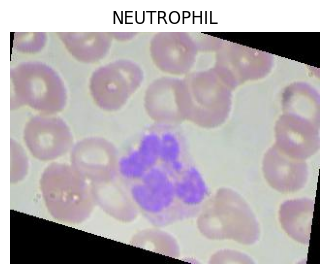

In [6]:
sample_cell_path, sample_cell_label = random.choice(train_ds_info.samples)
sample_cell_bgr = cv2.imread(sample_cell_path)
sample_cell_rgb = cv2.cvtColor(sample_cell_bgr, cv2.COLOR_BGR2RGB)

print("Sample cell:", sample_cell_path)
print("Ground truth:", train_ds_info.classes[sample_cell_label])

plt.figure(figsize=(4, 4))
plt.imshow(sample_cell_rgb)
plt.title(train_ds_info.classes[sample_cell_label])
plt.axis("off")
plt.show()


## 5. Khai báo weights


In [7]:
RBC_WEIGHTS = PROJECT_ROOT / "saved_models" / "rbc_yolo" / "weights" / "best.pt"
WBC_WEIGHTS = PROJECT_ROOT / "saved_models" / "wbc_classifier_best.pth"

print("RBC_WEIGHTS:", RBC_WEIGHTS)
print("WBC_WEIGHTS:", WBC_WEIGHTS)


RBC_WEIGHTS: f:\py\XLAS\HeaWeb\saved_models\rbc_yolo\weights\best.pt
WBC_WEIGHTS: f:\py\XLAS\HeaWeb\saved_models\wbc_classifier_best.pth


## 6. Load WBC classifier


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
wbc_model = None
wbc_class_names = train_ds_info.classes
classifier_img_size = 224

if WBC_WEIGHTS is not None and Path(WBC_WEIGHTS).exists():
    wbc_model, wbc_class_names, backbone, classifier_img_size = load_wbc_classifier(str(WBC_WEIGHTS), device=device)
    print("Loaded WBC classifier")
    print("Backbone:", backbone)
    print("Image size:", classifier_img_size)
    print("Classes:", wbc_class_names)
else:
    print("Chưa có WBC classifier weights. Hãy train classifier trước nếu muốn predict class thật.")


Loaded WBC classifier
Backbone: resnet18
Image size: 224
Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


## 7. Test classifier trên ảnh single-cell


In [9]:
if wbc_model is not None:
    pred = predict_class(wbc_model, sample_cell_bgr, wbc_class_names, device=device, img_size=classifier_img_size)
    print("Ground truth:", train_ds_info.classes[sample_cell_label])
    print("Prediction:", pred["label"])
    print("Score:", pred["score"])
else:
    print("B? qua v? ch?a load WBC classifier.")


Ground truth: NEUTROPHIL
Prediction: NEUTROPHIL
Score: 0.8419128060340881


## 8. Kiểm tra XML dataset-master là phần hỗ trợ RBC


In [10]:
xml_names = []
for xml_path in sorted(ANNOTATION_DIR.glob("*.xml")):
    root = ET.parse(xml_path).getroot()
    for obj in root.findall("object"):
        xml_names.append(obj.find("name").text)

counter = Counter(xml_names)
print(counter)
counter


Counter({'RBC': 3854})


Counter({'RBC': 3854})

## 9. Xem ảnh kính hiển vi đầy đủ


Sample microscope image: f:\py\XLAS\HeaWeb\dataset-master\dataset-master\JPEGImages\BloodImage_00367.jpg


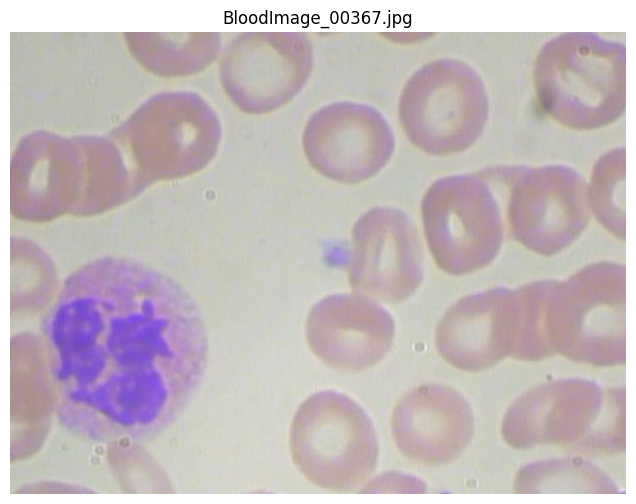

In [11]:
jpg_files = sorted(JPEG_DIR.glob("*.jpg"))
sample_image = random.choice(jpg_files)
img_bgr = cv2.imread(str(sample_image))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Sample microscope image:", sample_image)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title(sample_image.name)
plt.axis("off")
plt.show()


## 10. WBC proposal/crop tự động từ ảnh lớn


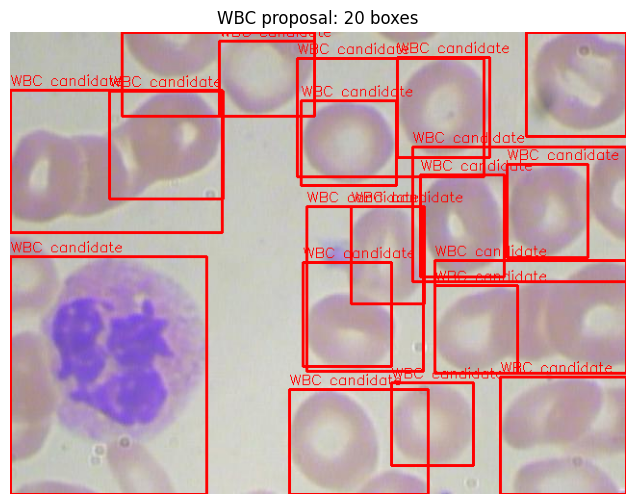

[[0, 233, 204, 480],
 [0, 60, 220, 208],
 [418, 119, 640, 259],
 [298, 27, 492, 150],
 [441, 237, 640, 354],
 [308, 181, 429, 352],
 [116, 0, 316, 87],
 [509, 358, 640, 480],
 [290, 371, 434, 480],
 [103, 61, 221, 173]]

In [12]:
proposal = WBCProposal(max_candidates=20)
wbc_boxes = proposal.propose(img_bgr)

vis = img_bgr.copy()
for x1, y1, x2, y2 in wbc_boxes:
    cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    cv2.putText(vis, "WBC candidate", (int(x1), max(0, int(y1)-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"WBC proposal: {len(wbc_boxes)} boxes")
plt.axis("off")
plt.show()

wbc_boxes[:10]


## 11. Xem các crop WBC candidate


Number of crops: 20


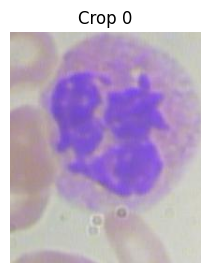

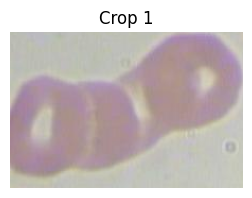

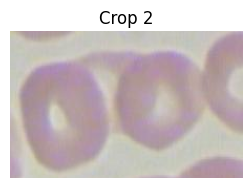

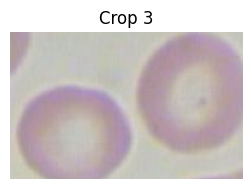

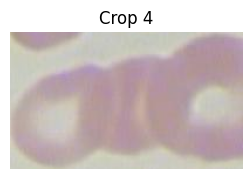

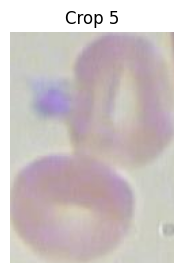

In [13]:
crops = proposal.crop_boxes(img_bgr, wbc_boxes)
print("Number of crops:", len(crops))

for i, crop in enumerate(crops[:6]):
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"Crop {i}")
    plt.axis("off")
    plt.show()


## 12. Classify crop candidate nếu đã có WBC classifier


In [14]:
if wbc_model is not None:
    for i, crop in enumerate(crops[:10]):
        pred = predict_class(wbc_model, crop, wbc_class_names, device=device, img_size=classifier_img_size)
        print(f"Crop {i}: {pred['label']} | score={pred['score']:.4f}")
else:
    print("B? qua v? ch?a load WBC classifier.")


Crop 0: EOSINOPHIL | score=1.0000
Crop 1: EOSINOPHIL | score=1.0000
Crop 2: EOSINOPHIL | score=0.9994
Crop 3: EOSINOPHIL | score=0.9996
Crop 4: EOSINOPHIL | score=1.0000
Crop 5: EOSINOPHIL | score=0.9671
Crop 6: EOSINOPHIL | score=1.0000
Crop 7: EOSINOPHIL | score=1.0000
Crop 8: EOSINOPHIL | score=0.9995
Crop 9: EOSINOPHIL | score=1.0000


## 13. Load RBC detector hỗ trợ


In [15]:
rbc_detector = None
rbc_boxes = []

if RBC_WEIGHTS is not None and Path(RBC_WEIGHTS).exists():
    rbc_detector = load_rbc_detector(model_type="yolov5", weights=str(RBC_WEIGHTS), classes=["RBC"], img_size=640, device=device)
    print("Loaded RBC detector")
else:
    print("Chưa có RBC detector weights. Có thể bỏ qua phần hỗ trợ RBC.")


Loaded RBC detector


## 14. Vẽ RBC boxes để kiểm tra



0: 480x640 16 RBCs, 87.6ms
Speed: 2.5ms preprocess, 87.6ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


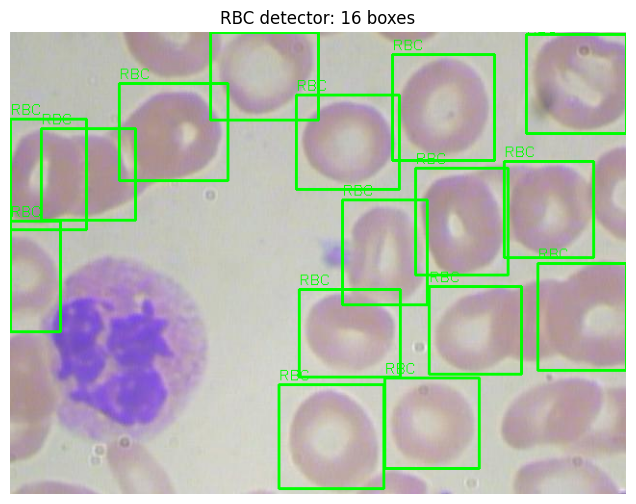

[[297.1678771972656, 65.86643981933594, 404.4795227050781, 163.2876739501953],
 [389.38800048828125, 359.9296875, 487.3260498046875, 453.78704833984375],
 [397.1112060546875, 23.007400512695312, 503.8433837890625, 133.1939697265625],
 [300.01318359375, 267.677490234375, 405.8109130859375, 358.73834228515625],
 [513.284423828125, 134.95111083984375, 606.1402587890625, 234.57293701171875],
 [421.16583251953125,
  141.44241333007812,
  517.3124389648438,
  252.53140258789062],
 [279.69873046875, 366.5791015625, 388.7440185546875, 474.418701171875],
 [435.35107421875, 264.33660888671875, 531.175537109375, 355.85552978515625],
 [536.552978515625, 2.601226806640625, 640.0, 105.32205200195312],
 [208.06349182128906, 0.609527587890625, 320.0673828125, 91.87808227539062]]

In [16]:
rbc_boxes = []
if rbc_detector is not None:
    preds = rbc_detector.detect([img_bgr])[0]
    if preds is not None and len(preds) > 0:
        rbc_boxes = preds[:, 1:5].tolist()
    vis_rbc = draw_boxes(img_bgr, rbc_boxes, label="RBC", color=(0, 255, 0))
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(vis_rbc, cv2.COLOR_BGR2RGB))
    plt.title(f"RBC detector: {len(rbc_boxes)} boxes")
    plt.axis("off")
    plt.show()
else:
    print("B? qua v? ch?a c? RBC detector.")

rbc_boxes[:10]


## 15. WBC proposal sau khi loại vùng RBC


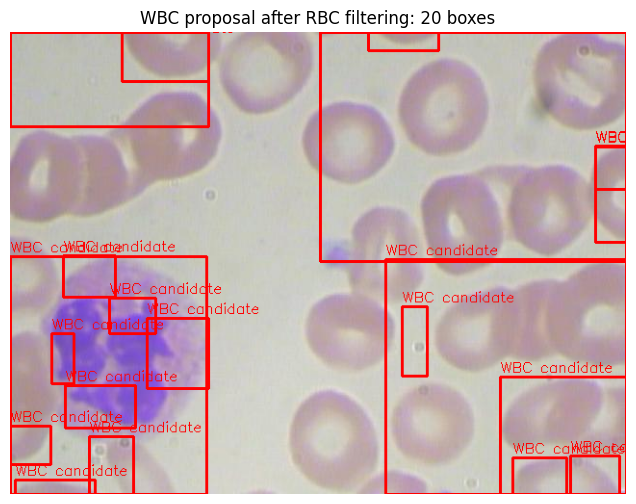

[[322, 0, 640, 238],
 [390, 236, 640, 480],
 [0, 233, 204, 480],
 [0, 0, 206, 98],
 [509, 358, 640, 480],
 [142, 297, 206, 370],
 [116, 0, 206, 51],
 [57, 367, 130, 411],
 [608, 118, 640, 218],
 [82, 420, 128, 480]]

In [17]:
filtered_wbc_boxes = proposal.propose(img_bgr, exclude_boxes=rbc_boxes)

vis_filtered = img_bgr.copy()
for x1, y1, x2, y2 in filtered_wbc_boxes:
    cv2.rectangle(vis_filtered, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 255), 2)
    cv2.putText(vis_filtered, "WBC candidate", (int(x1), max(0, int(y1)-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(vis_filtered, cv2.COLOR_BGR2RGB))
plt.title(f"WBC proposal after RBC filtering: {len(filtered_wbc_boxes)} boxes")
plt.axis("off")
plt.show()

filtered_wbc_boxes[:10]


## 16. Pipeline end-to-end



0: 480x640 16 RBCs, 58.4ms
Speed: 1.3ms preprocess, 58.4ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


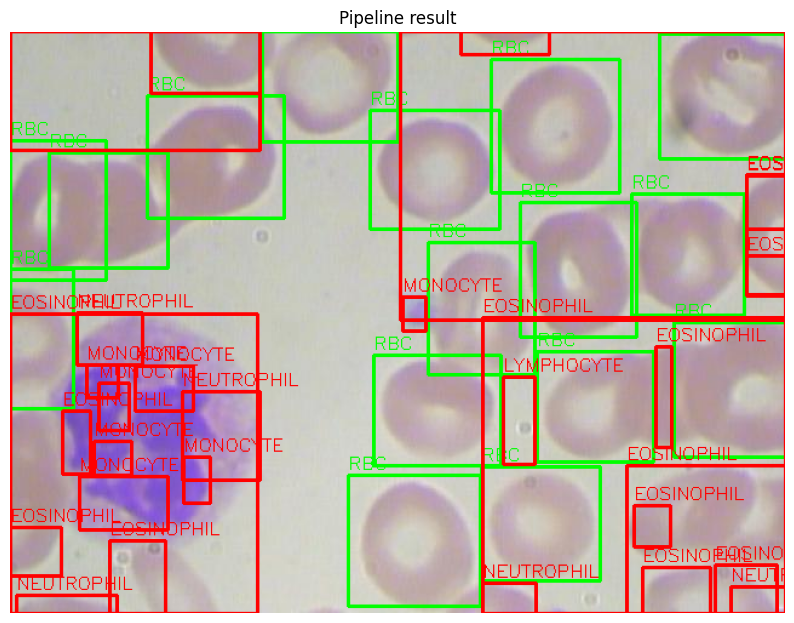

RBC boxes: 16
WBC boxes: 30
WBC predictions: [{'label': 'EOSINOPHIL', 'score': 0.7905367016792297, 'probs': [0.7905367016792297, 0.20913393795490265, 3.330618346808478e-05, 0.0002960564161185175], 'class_index': 0}, {'label': 'EOSINOPHIL', 'score': 1.0, 'probs': [1.0, 6.989663958734127e-09, 3.286436367488932e-08, 3.164479878137172e-08], 'class_index': 0}, {'label': 'EOSINOPHIL', 'score': 0.999994158744812, 'probs': [0.999994158744812, 1.213697111562828e-13, 1.2920874326027842e-07, 5.779113052994944e-06], 'class_index': 0}, {'label': 'EOSINOPHIL', 'score': 0.9958166480064392, 'probs': [0.9958166480064392, 0.004136211704462767, 3.7553302134618605e-10, 4.710269786301069e-05], 'class_index': 0}, {'label': 'EOSINOPHIL', 'score': 0.9999998807907104, 'probs': [0.9999998807907104, 3.2246014192161e-10, 2.9837622150807874e-08, 1.690558377731577e-07], 'class_index': 0}, {'label': 'NEUTROPHIL', 'score': 0.9999765157699585, 'probs': [2.3455204427591525e-05, 7.477741192492442e-17, 3.702259609994485e

In [18]:
pipeline = CellPipeline(
    rbc_detector=rbc_detector,
    wbc_classifier=wbc_model,
    wbc_class_names=wbc_class_names,
    img_size=classifier_img_size,
    device=device,
)

result = pipeline.run(str(sample_image))
vis = pipeline.draw_result(result)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Pipeline result")
plt.axis("off")
plt.show()

print("RBC boxes:", len(result["rbc_boxes"]))
print("WBC boxes:", len(result["wbc_boxes"]))
print("WBC predictions:", result["wbc_predictions"])


## 17. Train WBC classifier - bước chính


In [4]:
try:
    run([
        sys.executable, "-m", "src.train",
        "--task", "classification",
        "--train_root", str(TRAIN_DIR),
        "--val_root", str(TEST_DIR),
        "--backbone", "resnet18",
        "--img_size", "224",
        "--batch_size", "16",
        "--epochs", "10",
        "--save_dir", str(PROJECT_ROOT / "saved_models"),
    ], check=True)
except Exception as e:
    print("Train failed:", e)


Train failed: name 'TRAIN_DIR' is not defined


## 18. Convert annotation và train RBC detector hỗ trợ


In [ ]:
converter = AnnotationConverter(
    annotations_dir=str(ANNOTATION_DIR),
    output_dir=str(DATASET_MASTER / "YOLO_labels"),
    classes=["RBC"],
)
df = converter.convert_all_xml()
print(df["class_id"].value_counts().sort_index())

run([
    sys.executable, "-m", "src.train",
    "--task", "detection",
    "--model", "yolov5",
    "--img_dir", str(JPEG_DIR),
    "--ann_file", str(DATASET_MASTER / "YOLO_labels" / "annotations_converted.csv"),
    "--classes", "RBC",
    "--epochs", "20",
    "--batch_size", "4",
    "--img_size", "640",
    "--save_dir", str(PROJECT_ROOT / "saved_models"),
], check=True)
